## Actividad 3_15: Uso de KMeans para clasificación de clientes
<div style="border-style:groove;border-width:thin;padding:10px">
En este ejercicio vamos a utilizar KMeans para segmetar o clasificar a un grupo de clientes. En este caso se trata de los clientes de una empresa que vende una gran variedad de cosas. Vamos a utilizar un dataset de una campaña de márketing de una empresa que contiene datos de sus clientes. Estos datos son muy variados. Van desde la fecha de nacimiento hasta lo que han gastado en fruta pasando por el estado civil. 
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
1. Cargamos el dataset.
</div>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("marketing_campaign.csv",sep='\t')
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


<div style="border-style:groove;border-width:thin;padding:10px">
2. Borra la columna ID, ya que no nos aporta nada para segmentar los clientes. Cambia la Columna 'Year_Birth' por una con la edad de cada cliente. Pinta un gráfico de la distribución de edad. Puedes usar sns.violinplot para hacerlo. Consulta la documentación. Es una herramienta sencilla para pintar la distribución de una población por edad.
</div>

In [3]:

real_years = []
for index, row in df.iterrows():
    real_years.append(2024 - row['Year_Birth'])
df['Real_Age'] = real_years
df.drop(columns=['ID','Year_Birth'], inplace=True)
df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Real_Age
0,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,...,0,0,0,0,0,0,3,11,1,67
1,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,...,0,0,0,0,0,0,3,11,0,70
2,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,...,0,0,0,0,0,0,3,11,0,59
3,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,...,0,0,0,0,0,0,3,11,0,40
4,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,...,0,0,0,0,0,0,3,11,0,43


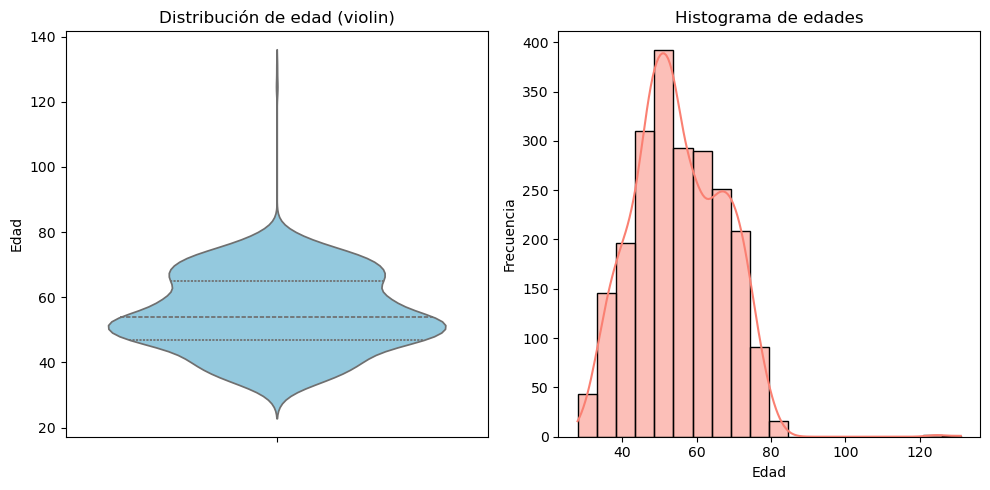

In [4]:
plt.figure(figsize=(10,5))

# Violin plot
plt.subplot(1,2,1)
sns.violinplot(y='Real_Age', data=df, inner='quartile', color='skyblue')
plt.title('Distribución de edad (violin)')
plt.ylabel('Edad')
plt.xlabel('')

# Histograma + KDE
plt.subplot(1,2,2)
sns.histplot(df['Real_Age'], bins=20, kde=True, color='salmon')
plt.title('Histograma de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
3. ¿Ves algo raro en la distribución? Elimina los datos que consideres que deben ser eliminados y vuelve a pintar la distribución por edad.
</div>

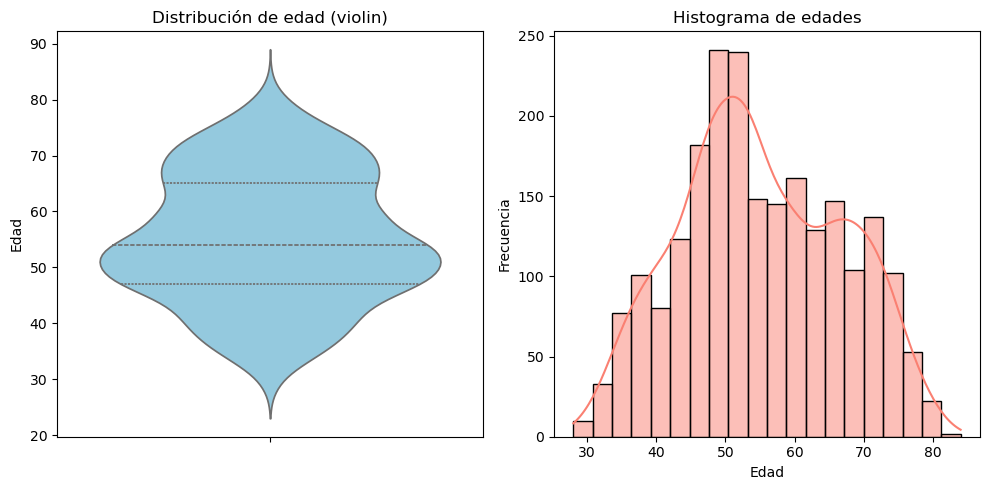

In [5]:
# Filter data to keep only people with age < 90
df = df[df['Real_Age'] < 90]

# Recreate the violin plot and histogram
plt.figure(figsize=(10,5))

# Violin plot
plt.subplot(1,2,1)
sns.violinplot(y='Real_Age', data=df, inner='quartile', color='skyblue')
plt.title('Distribución de edad (violin)')
plt.ylabel('Edad')
plt.xlabel('')

# Histograma + KDE
plt.subplot(1,2,2)
sns.histplot(df['Real_Age'], bins=20, kde=True, color='salmon')
plt.title('Histograma de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')

plt.tight_layout()
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
4. Pinta un gráfico de barras (sns.barplot) con el número de individuos por nivel educativo. Puedes usar también  df.Education.value_counts().
</div>

/tmp/ipykernel_15579/993631635.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=education_counts.index, y=education_counts.values, palette='viridis')


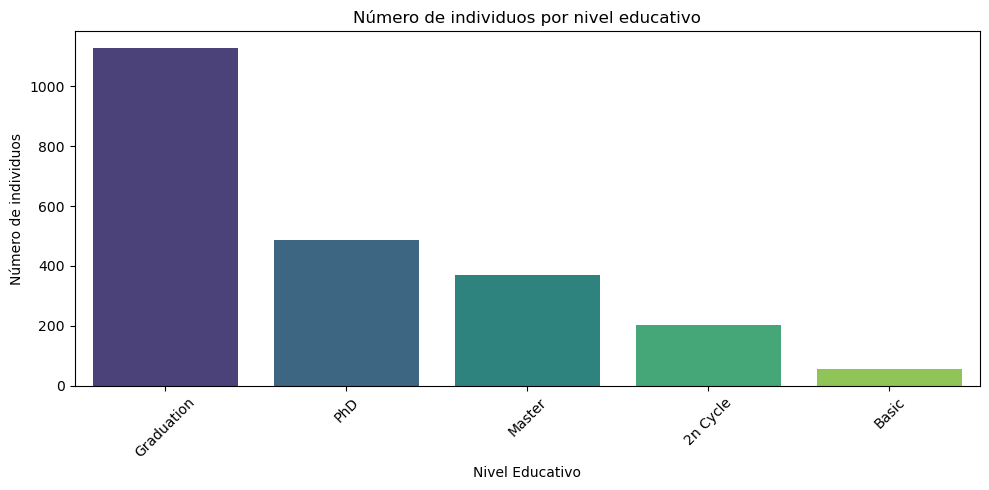

In [6]:
# Gráfico de barras con el número de individuos por nivel educativo
plt.figure(figsize=(10, 5))

# Opción 1: Usando value_counts()
education_counts = df['Education'].value_counts()
sns.barplot(x=education_counts.index, y=education_counts.values, palette='viridis')
plt.title('Número de individuos por nivel educativo')
plt.xlabel('Nivel Educativo')
plt.ylabel('Número de individuos')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
5. Pinta ahora un gráfico de barras del sueldo medio por nivel educativo.
</div>

/tmp/ipykernel_15579/2713478466.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_income_by_education.index, y=avg_income_by_education.values, palette='viridis')


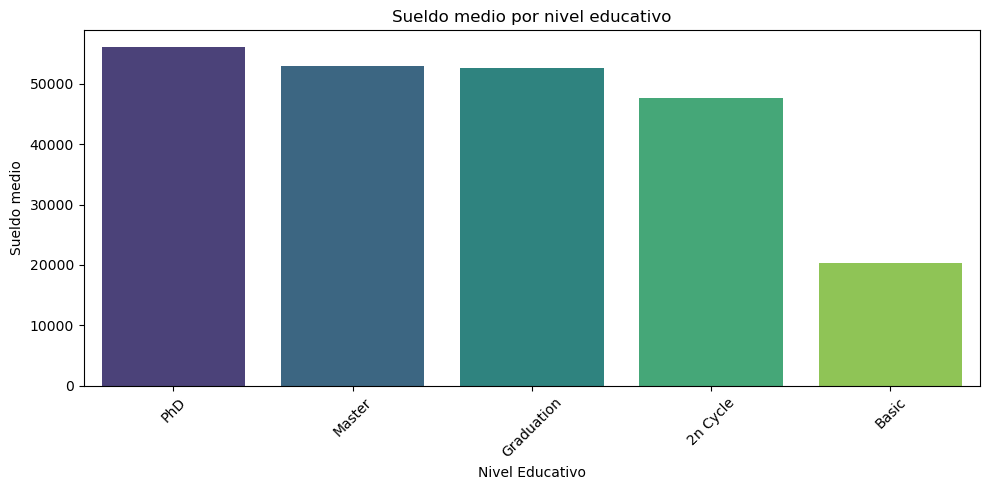

In [7]:
# Calculate average income by education level
avg_income_by_education = df.groupby('Education')['Income'].mean().sort_values(ascending=False)

# Create bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_income_by_education.index, y=avg_income_by_education.values, palette='viridis')
plt.title('Sueldo medio por nivel educativo')
plt.xlabel('Nivel Educativo')
plt.ylabel('Sueldo medio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
6. Pinta un gráfico de barras del sueldo por tramos de edades de 20 en 20 años.
</div>

/tmp/ipykernel_15579/3605452402.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_income_by_age = df.groupby('Age_Group')['Income'].mean()
/tmp/ipykernel_15579/3605452402.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_income_by_age.index.astype(str), y=avg_income_by_age.values, palette='viridis')


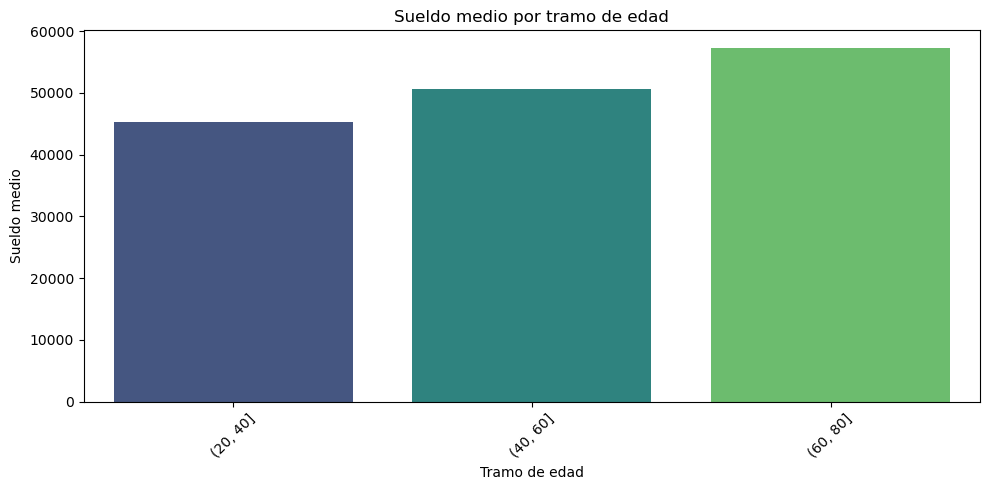

In [8]:
# Create age bins of 20 years
age_bins = range(20, 100, 20)
df['Age_Group'] = pd.cut(df['Real_Age'], bins=age_bins)

# Calculate average income by age group
avg_income_by_age = df.groupby('Age_Group')['Income'].mean()

# Create bar plot
plt.figure(figsize=(10, 5))
sns.barplot(x=avg_income_by_age.index.astype(str), y=avg_income_by_age.values, palette='viridis')
plt.title('Sueldo medio por tramo de edad')
plt.xlabel('Tramo de edad')
plt.ylabel('Sueldo medio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<div style="border-style:groove;border-width:thin;padding:10px">
7. Cambia las columnas categóricas por valores numéricos (con el método que prefieras) y elimina los valores nulos (recuerda que se hace con dropna).
</div>

In [9]:
from sklearn.preprocessing import LabelEncoder

# Convert categorical columns to numeric
le_education = LabelEncoder()
le_marital = LabelEncoder()

df['Education'] = le_education.fit_transform(df['Education'])
df['Marital_Status'] = le_marital.fit_transform(df['Marital_Status'])

# Drop null values
df = df.dropna()

# Drop the Age_Group column as it's no longer needed (we have Real_Age)
df = df.drop(columns=['Age_Group', 'Dt_Customer'])

df.head()

,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Real_Age
0,2,4,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,0,0,3,11,1,67
1,2,4,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,0,3,11,0,70
2,2,5,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,0,3,11,0,59
3,2,5,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,0,3,11,0,40
4,4,3,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,0,3,11,0,43


<div style="border-style:groove;border-width:thin;padding:10px">
    <p>Ahora vamos a implementar el <b>METODO DEL CODO</b>. Este método consiste en hacer el método KMeans con distintos números de clusters (k). Después se calcula la suma de los Errores Cuadráticos Medios en cada Cluster (WCSS). Se pinta la gráfica de los WCSS para cada valor de k y te quedas con el valor del "codo", es decir, a partir del cual el WCSS baja bastante despacio.</p>
    <p>Los pasos serían los siguientes:</p>
    <ol>
        <li>Realiza el KMeans con valores de k de 0 a 10 o 15, por ejemplo.</li>
        <li>Guarda el dato kmeans.inertia_ para cada valor de k en una lista (este valor se corresponde con el WCSS)</li>
        <li>Pinta la lista de WCSS vs k.</li>
        <li>Busca el valor adecuado del "codo".</li>
    </ol>
</div>

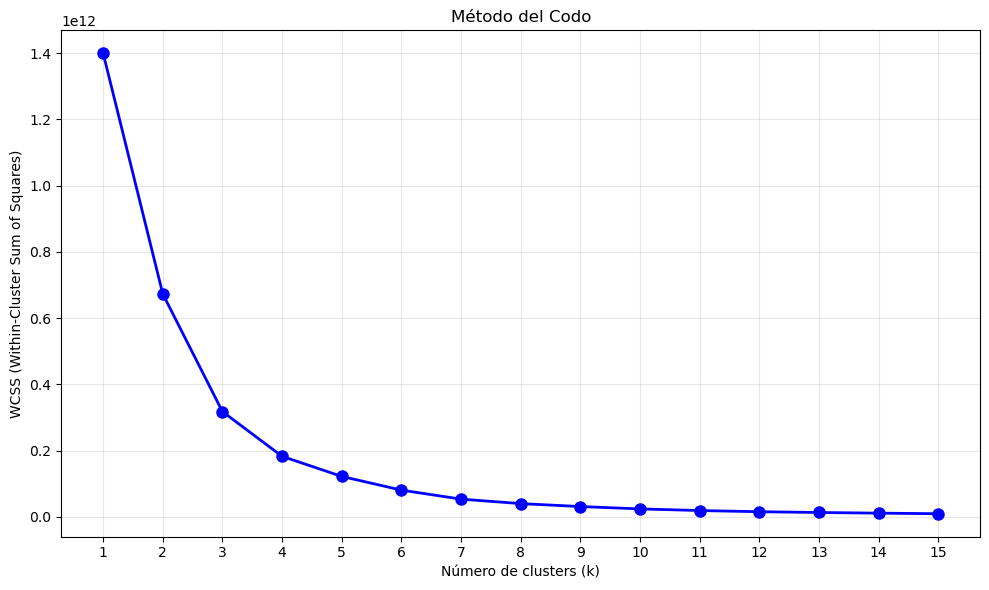

WCSS values for each k:
k=1: WCSS=1399620860457.49
k=2: WCSS=672855913310.20
k=3: WCSS=317605104822.01
k=4: WCSS=182587871197.30
k=5: WCSS=121897338323.43
k=6: WCSS=80558989703.19
k=7: WCSS=53275835085.75
k=8: WCSS=39829137481.08
k=9: WCSS=30908840007.06
k=10: WCSS=23795655134.85
k=11: WCSS=18870209791.74
k=12: WCSS=15280118331.93
k=13: WCSS=12956331210.18
k=14: WCSS=10947699381.44
k=15: WCSS=9302158195.91


In [10]:
from sklearn.cluster import KMeans

# Prepare data: drop non-numeric columns and handle missing values
df_kmeans = df.select_dtypes(include=[np.number]).dropna()

# Implement elbow method
wcss = []
k_range = range(1, 16)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_kmeans)
    wcss.append(kmeans.inertia_)

# Plot WCSS vs k
plt.figure(figsize=(10, 6))
plt.plot(k_range, wcss, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Método del Codo')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)
plt.tight_layout()
plt.show()

print("WCSS values for each k:")
for k, w in zip(k_range, wcss):
    print(f"k={k}: WCSS={w:.2f}")

<div style="border-style:groove;border-width:thin;padding:10px">
    <p>8. Implementa el método del codo con el dataset actual y anota el valor adecuado de k.</p>
</div>

<div style="border-style:groove;border-width:thin;padding:10px">
9. Ahora implementa KMeans con el número obtenido anteriomente y guarda las etiquetas en una columna nueva del dataframe.
</div>

In [11]:
# Apply KMeans with optimal k (based on elbow method, k=3 appears reasonable)
optimal_k = 3
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_kmeans['Cluster'] = kmeans_final.fit_predict(df_kmeans)

# Add cluster labels to original dataframe
df['Cluster'] = df_kmeans['Cluster']

print(f"KMeans applied with k={optimal_k}")
print(f"Cluster distribution:")
print(df['Cluster'].value_counts().sort_index())
print("\nDataframe with clusters:")
df.head(10)

KMeans applied with k=3
Cluster distribution:
Cluster
0    1073
1    1131
2       1
Name: count, dtype: int64

Dataframe with clusters:


,Education,Marital_Status,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Real_Age,Cluster
0,2,4,58138.0,0,0,58,635,88,546,172,...,0,0,0,0,0,3,11,1,67,0
1,2,4,46344.0,1,1,38,11,1,6,2,...,0,0,0,0,0,3,11,0,70,1
2,2,5,71613.0,0,0,26,426,49,127,111,...,0,0,0,0,0,3,11,0,59,0
3,2,5,26646.0,1,0,26,11,4,20,10,...,0,0,0,0,0,3,11,0,40,1
4,4,3,58293.0,1,0,94,173,43,118,46,...,0,0,0,0,0,3,11,0,43,0
5,3,5,62513.0,0,1,16,520,42,98,0,...,0,0,0,0,0,3,11,0,57,0
6,2,2,55635.0,0,1,34,235,65,164,50,...,0,0,0,0,0,3,11,0,53,0
7,4,3,33454.0,1,0,32,76,10,56,3,...,0,0,0,0,0,3,11,0,39,1
8,4,5,30351.0,1,0,19,14,0,24,3,...,0,0,0,0,0,3,11,1,50,1
9,4,5,5648.0,1,1,68,28,0,6,1,...,0,0,0,0,0,3,11,0,74,1


<div style="border-style:groove;border-width:thin;padding:10px">
10. Crea un dataframe nuevo con los datos del original pero quédate solo con las columnas que tienen valores significativos para nosotros. Vamos a ver si encontramos relaciones entre los clientes de un cluster (el 0, por ejemplo). Pinta los valores del dataframe (por ejemplo, el nivel educativo, el estado civil, los ingresos, el número total de hijos, el número total de gasto y la edad) de los individuos de la clase 0. ¿Identificas alguna relación?
</div>

Number of customers in Cluster 0: 1073

Statistics for Cluster 0:
         Education  Marital_Status         Income   Total_Kids  \
count  1073.000000     1073.000000    1073.000000  1073.000000   
mean      2.500466        3.715750   70262.645853     0.696179   
std       1.096232        1.096255   12913.758189     0.715601   
min       0.000000        0.000000   52413.000000     0.000000   
25%       2.000000        3.000000   61064.000000     0.000000   
50%       2.000000        3.000000   69084.000000     1.000000   
75%       3.000000        5.000000   77981.000000     1.000000   
max       4.000000        6.000000  162397.000000     3.000000   

       Total_Spending     Real_Age  
count      1073.00000  1073.000000  
mean       1072.65424    57.128611  
std         523.72972    11.724538  
min           6.00000    29.000000  
25%         702.00000    49.000000  
50%        1049.00000    57.000000  
75%        1443.00000    67.000000  
max        2525.00000    80.000000  


Deta

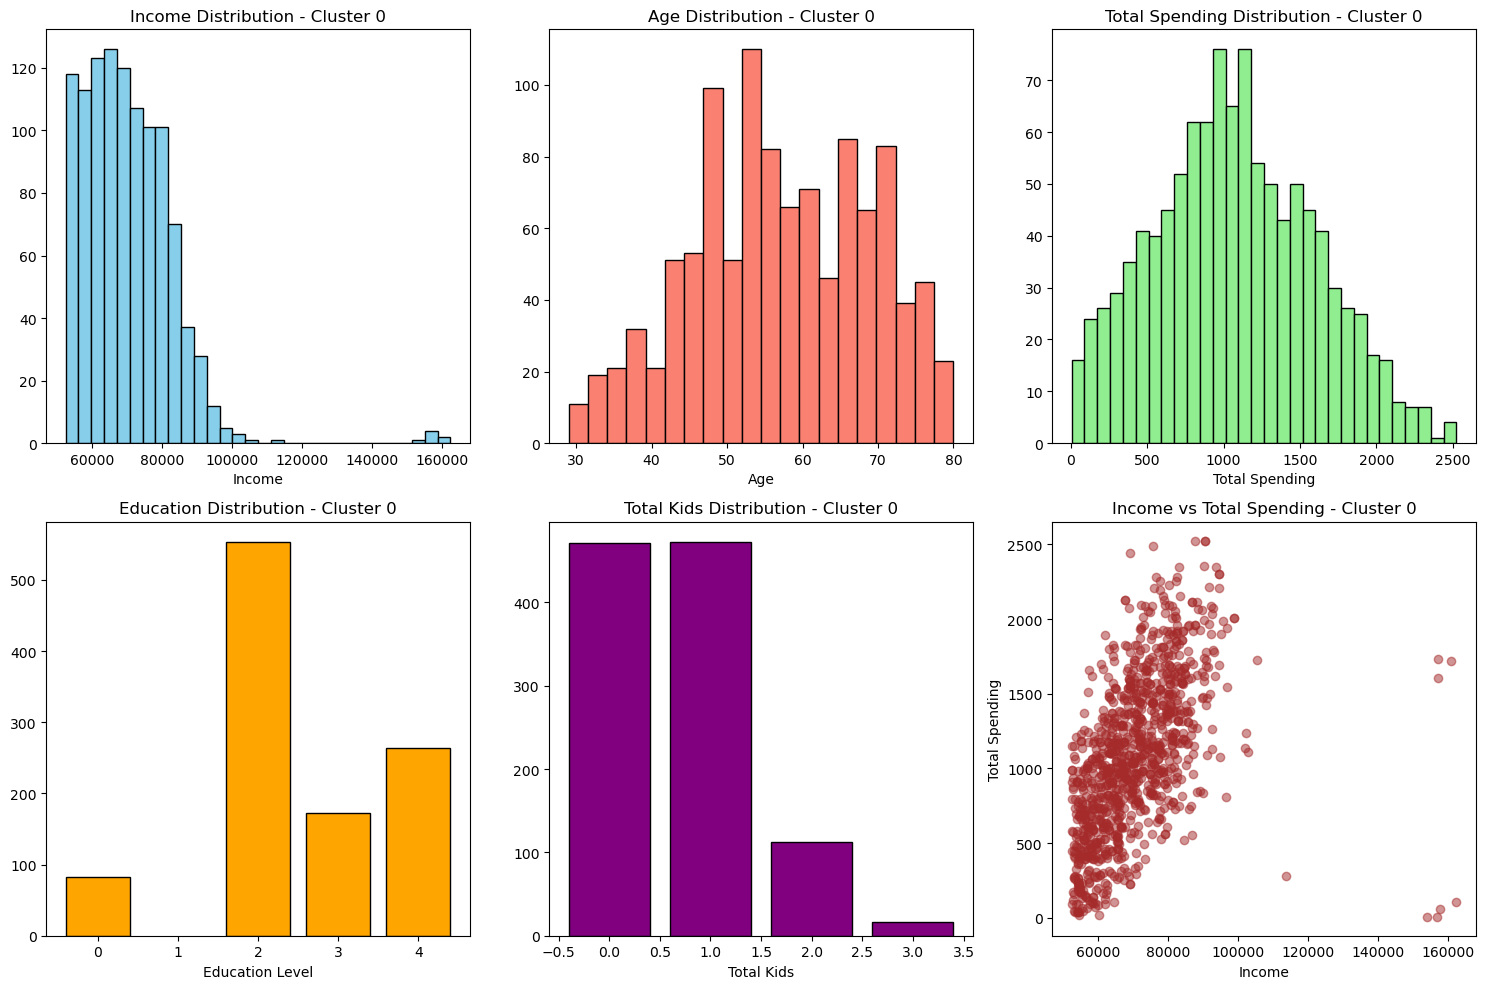

In [12]:
# Create a new dataframe with significant columns
significant_columns = ['Education', 'Marital_Status', 'Income', 'Kidhome', 'Teenhome', 
                       'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 
                       'MntSweetProducts', 'MntGoldProds', 'Real_Age', 'Cluster']

df_analysis = df[significant_columns].copy()

# Calculate total spending per customer
df_analysis['Total_Spending'] = (df_analysis['MntWines'] + df_analysis['MntFruits'] + 
                                  df_analysis['MntMeatProducts'] + df_analysis['MntFishProducts'] + 
                                  df_analysis['MntSweetProducts'] + df_analysis['MntGoldProds'])

# Calculate total kids
df_analysis['Total_Kids'] = df_analysis['Kidhome'] + df_analysis['Teenhome']

# Filter for cluster 0
cluster_0 = df_analysis[df_analysis['Cluster'] == 0]

print(f"Number of customers in Cluster 0: {len(cluster_0)}")
print("\nStatistics for Cluster 0:")
print(cluster_0[['Education', 'Marital_Status', 'Income', 'Total_Kids', 'Total_Spending', 'Real_Age']].describe())

print("\n\nDetailed view of first 10 customers in Cluster 0:")
print(cluster_0[['Education', 'Marital_Status', 'Income', 'Total_Kids', 'Total_Spending', 'Real_Age']].head(10))

# Create visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Income distribution
axes[0, 0].hist(cluster_0['Income'], bins=30, color='skyblue', edgecolor='black')
axes[0, 0].set_title('Income Distribution - Cluster 0')
axes[0, 0].set_xlabel('Income')

# Age distribution
axes[0, 1].hist(cluster_0['Real_Age'], bins=20, color='salmon', edgecolor='black')
axes[0, 1].set_title('Age Distribution - Cluster 0')
axes[0, 1].set_xlabel('Age')

# Total spending distribution
axes[0, 2].hist(cluster_0['Total_Spending'], bins=30, color='lightgreen', edgecolor='black')
axes[0, 2].set_title('Total Spending Distribution - Cluster 0')
axes[0, 2].set_xlabel('Total Spending')

# Education distribution
education_dist = cluster_0['Education'].value_counts()
axes[1, 0].bar(education_dist.index, education_dist.values, color='orange', edgecolor='black')
axes[1, 0].set_title('Education Distribution - Cluster 0')
axes[1, 0].set_xlabel('Education Level')

# Total kids distribution
kids_dist = cluster_0['Total_Kids'].value_counts().sort_index()
axes[1, 1].bar(kids_dist.index, kids_dist.values, color='purple', edgecolor='black')
axes[1, 1].set_title('Total Kids Distribution - Cluster 0')
axes[1, 1].set_xlabel('Total Kids')

# Income vs Total Spending scatter
axes[1, 2].scatter(cluster_0['Income'], cluster_0['Total_Spending'], alpha=0.5, color='brown')
axes[1, 2].set_title('Income vs Total Spending - Cluster 0')
axes[1, 2].set_xlabel('Income')
axes[1, 2].set_ylabel('Total Spending')

plt.tight_layout()
plt.show()